# `boundaries`: Exploration

This notebook is a place to work out processing steps before we move them into the production pipeline.

max.koehler@swr.de

In [1]:
import geopandas as gp
import shapely as shp
from matplotlib import pyplot as plt

In [2]:
data = {}
for k in ["STA", "LAN", "KRS"]:
    data[k] = gp.read_file(f"zip://../tmp/raw/2025-01-01_vg250_01-01.utm32s.shape.ebenen.zip!vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_{k}.shp")

data["subs"] =  gp.read_file("../label_substitutions.geojson")


## Länder labels

See:

- https://github.com/mapbox/polylabel
- https://github.com/mapbox/polylabel/pull/63#issuecomment-646107909
- https://observablehq.com/@mourner/labeling-with-stretched-polylabel

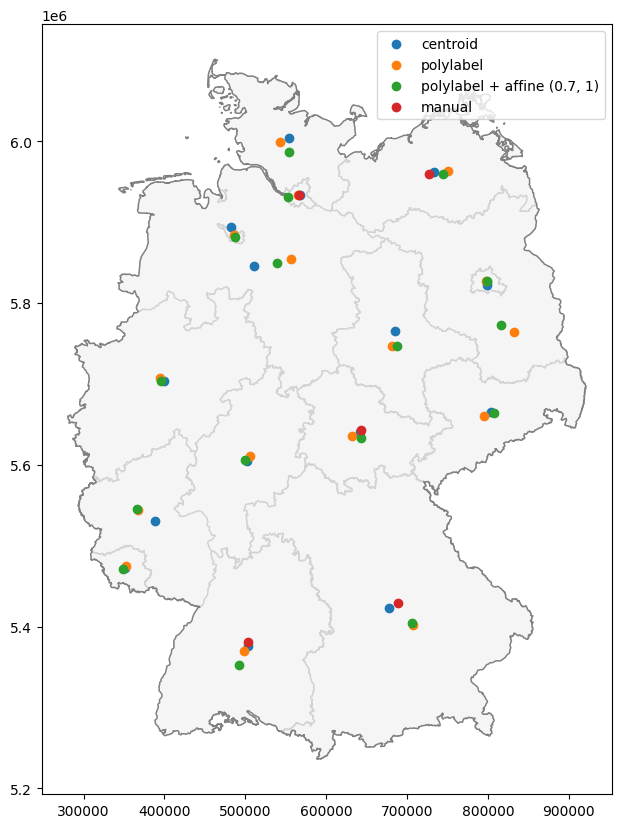

In [3]:
fig,ax = plt.subplots(figsize=(8, 10))
data["LAN"].loc[data["LAN"]["GF"] == 4].plot(ax=ax, color="whitesmoke", edgecolor="lightgray")
data["STA"].loc[data["STA"]["GF"] == 4].plot(ax=ax, color="None", edgecolor="gray")

r = data["LAN"].loc[data["LAN"]["GF"] == 4]

centroids = r.copy()
centroids["geometry"] = centroids.geometry.apply(lambda x: x.centroid)
centroids.plot(ax=ax, label="centroid")

pl = r.copy()
pl["geometry"] = pl.geometry.apply(lambda x: shp.ops.polylabel(x, 10))
pl.plot(ax=ax, label="polylabel")

pl_aff = r.copy()
xfact = .7  
pl_aff["geometry"] = pl_aff.geometry.apply(lambda x: shp.ops.polylabel(shp.affinity.scale(x, xfact, yfact=1), 1))
pl_aff["geometry"] = pl_aff.geometry.apply(lambda x: shp.affinity.scale(x, 1 / xfact, yfact=1))
pl_aff.plot(ax=ax, label=f"polylabel + affine ({xfact}, 1)")

# subs = data["subs"].set_index("ars").to_dict(orient="index")
data["subs"].to_crs(data["LAN"].crs).plot(ax=ax, label="manual")

plt.legend()
plt.show()

## Bad multipolygon labels

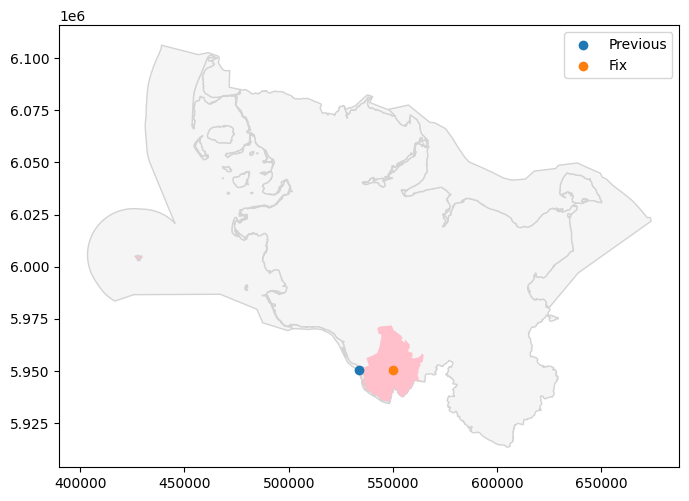

In [29]:
fig,ax = plt.subplots(figsize=(8, 10))
data["LAN"].loc[data["LAN"]["ARS"] == "01"].plot(ax=ax, color="whitesmoke", edgecolor="lightgray")

d =  data["KRS"].loc[(data["KRS"]["GEN"] == "Pinneberg") & (data["KRS"]["GF"] == 4)]
d.plot(ax=ax, color="pink")

pl = d.copy()
pl_fix = d.copy()

def get_label_point(x: shp.geometry.Polygon | shp.geometry.MultiPolygon, filter_largest: bool = False ):
	xfact = 0.7
	
	if (filter_largest):
		geom = x if isinstance(x, shp.geometry.Polygon) else max(x.geoms, key=lambda x: x.area)
	else:
		geom = x

	return shp.affinity.scale(
		shp.ops.polylabel(shp.affinity.scale(geom, xfact=xfact, yfact=1), 0.1),
		xfact=1 / xfact,
		yfact=1,
	)
	

pl["geometry"] = pl.geometry.apply(lambda x: get_label_point(x, False))
pl_fix["geometry"] = pl_fix.geometry.apply(lambda x: get_label_point(x, True))

pl.plot(ax=ax, label="Previous")
pl_fix.plot(ax=ax, label="Fix")
plt.legend()